In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

In [ ]:
!pip install koreanize-matplotlib

# IMPORT

In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib import rc
import math
from sklearn.preprocessing import StandardScaler
from random import shuffle

In [2]:
# 시스템에서 사용할 수 있는 한글 폰트 확인
for font in fm.findSystemFonts():
    if 'Nanum' in font or 'Malgun' in font or 'AppleGothic' in font:
        print(font)

# 한글 폰트 경로 설정 
import platform
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 기본 한글 폰트 (맑은 고딕)
elif platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')  # macOS의 기본 한글 폰트 (애플 고딕)
else:  # Linux
    rc('font', family='NanumGothic')  # Linux에서는 나눔고딕을 사용 (설치 필요)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.titlepad'] = 10

In [94]:
data = pd.read_excel('C:\\Users\\human\\Python-Web\\testdata.xlsx')

In [282]:
data = pd.read_excel('C:\\Users\\human\\Python-Web\\data3.xlsx')

In [283]:
data

,ID,개인프로젝트희망,실무경험,학습기간,전공여부,자신있는언어,자신없는언어,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장추천ID,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,12. 11번에서 팀장으로 선정한 이유를 간단히 적어 주세요.
0,S104,아니오,0.0,6개월 미만,0.0,"python, sql",java,80% 이하,3.0,1.0,3.0,0,S102,NaN,NaN,NaN,NaN,NaN,NaN
1,S106,예,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S107,아니오,0.0,6개월 미만,0.0,HTML,NaN,10% 이하,1.0,1.0,2.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S103,아니오,0.0,6개월 미만,0.0,"python, javascript",sql,81% 이상,4.0,4.0,3.0,90,S102,NaN,NaN,NaN,NaN,NaN,NaN
4,S108,아니오,0.0,6개월 미만,0.0,Python,"Java, JavaScript",50% 이하,2.0,2.0,2.0,60,S103,NaN,NaN,NaN,NaN,NaN,NaN
5,S109,아니오,0.0,6개월 미만,1.0,"Java, JavaScript",SQL,50% 이하,4.0,3.0,4.0,80,S102,NaN,NaN,NaN,NaN,NaN,NaN
6,S110,아니오,0.0,6개월 미만,0.0,SQL,JavaScript,50% 이하,3.0,1.0,3.0,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,S105,아니오,0.0,6개월 미만,0.0,Java,"Sql, JavaScript",50% 이하,2.0,1.0,1.0,0,S103,NaN,NaN,NaN,NaN,NaN,NaN
8,S116,예,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,S102,아니오,0.0,6개월 이상 ~ 12개월 미만,1.0,python,NaN,81% 이상,3.0,3.0,3.0,80,S103,NaN,NaN,NaN,NaN,NaN,NaN


In [284]:
data = data[data['개인프로젝트희망'] != '예']

In [285]:
data

,ID,개인프로젝트희망,실무경험,학습기간,전공여부,자신있는언어,자신없는언어,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장추천ID,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,12. 11번에서 팀장으로 선정한 이유를 간단히 적어 주세요.
0,S104,아니오,0.0,6개월 미만,0.0,"python, sql",java,80% 이하,3.0,1.0,3.0,0,S102,NaN,NaN,NaN,NaN,NaN,NaN
2,S107,아니오,0.0,6개월 미만,0.0,HTML,NaN,10% 이하,1.0,1.0,2.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S103,아니오,0.0,6개월 미만,0.0,"python, javascript",sql,81% 이상,4.0,4.0,3.0,90,S102,NaN,NaN,NaN,NaN,NaN,NaN
4,S108,아니오,0.0,6개월 미만,0.0,Python,"Java, JavaScript",50% 이하,2.0,2.0,2.0,60,S103,NaN,NaN,NaN,NaN,NaN,NaN
5,S109,아니오,0.0,6개월 미만,1.0,"Java, JavaScript",SQL,50% 이하,4.0,3.0,4.0,80,S102,NaN,NaN,NaN,NaN,NaN,NaN
6,S110,아니오,0.0,6개월 미만,0.0,SQL,JavaScript,50% 이하,3.0,1.0,3.0,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,S105,아니오,0.0,6개월 미만,0.0,Java,"Sql, JavaScript",50% 이하,2.0,1.0,1.0,0,S103,NaN,NaN,NaN,NaN,NaN,NaN
9,S102,아니오,0.0,6개월 이상 ~ 12개월 미만,1.0,python,NaN,81% 이상,3.0,3.0,3.0,80,S103,NaN,NaN,NaN,NaN,NaN,NaN
10,S111,아니오,0.0,6개월 미만,1.0,java,JavaScript,50% 이하,1.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,S101,아니오,0.0,6개월 미만,1.0,java,javaScript,50% 이하,2.0,1.0,2.0,0,S104,NaN,NaN,NaN,NaN,NaN,NaN


# 데이터 전처리

## 텍스트 정리
추천 이유 등의 주관식 응답은 분석 제외 또는 워드 클라우드 용도로 처리

In [286]:
# 불필요 항목 제거
data.drop(columns=['개인프로젝트희망', '12. 11번에서 팀장으로 선정한 이유를 간단히 적어 주세요.', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17'], inplace=True)

C:\Users\human\AppData\Local\Temp\ipykernel_10368\3961169051.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['개인프로젝트희망', '12. 11번에서 팀장으로 선정한 이유를 간단히 적어 주세요.', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17'], inplace=True)


In [287]:
data.drop(columns=['Unnamed: 13'], inplace=True)

C:\Users\human\AppData\Local\Temp\ipykernel_10368\2497581260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['Unnamed: 13'], inplace=True)


In [288]:
data

,ID,실무경험,학습기간,전공여부,자신있는언어,자신없는언어,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장추천ID
0,S104,0.0,6개월 미만,0.0,"python, sql",java,80% 이하,3.0,1.0,3.0,0,S102
2,S107,0.0,6개월 미만,0.0,HTML,NaN,10% 이하,1.0,1.0,2.0,0,NaN
3,S103,0.0,6개월 미만,0.0,"python, javascript",sql,81% 이상,4.0,4.0,3.0,90,S102
4,S108,0.0,6개월 미만,0.0,Python,"Java, JavaScript",50% 이하,2.0,2.0,2.0,60,S103
5,S109,0.0,6개월 미만,1.0,"Java, JavaScript",SQL,50% 이하,4.0,3.0,4.0,80,S102
6,S110,0.0,6개월 미만,0.0,SQL,JavaScript,50% 이하,3.0,1.0,3.0,50,NaN
7,S105,0.0,6개월 미만,0.0,Java,"Sql, JavaScript",50% 이하,2.0,1.0,1.0,0,S103
9,S102,0.0,6개월 이상 ~ 12개월 미만,1.0,python,NaN,81% 이상,3.0,3.0,3.0,80,S103
10,S111,0.0,6개월 미만,1.0,java,JavaScript,50% 이하,1.0,1.0,1.0,0,NaN
12,S101,0.0,6개월 미만,1.0,java,javaScript,50% 이하,2.0,1.0,2.0,0,S104


## 중복값 제거
ID 중복 여부 확인 및 제거

In [289]:
print(len(data['ID'].unique()), len(data))  # 전체 데이터 크기 == ID의 unique값 임으로 처리 x

12 12


## 문자열 정규화
“예/아니오” → “1/0”, “3년 이상” → “3” 등 수치형 변환

In [290]:
# 문자열 정규화

data['실무경험'].unique()   # array(['0년', '1년', '3년 이상', '2년'], dtype=object)
data['학습기간'].unique()   # array(['12개월', '6개월', '24개월 이상', '18개월'], dtype=object)
data['전공여부'].unique()   # array(['관련 전공자', '비전공자'], dtype=object)
data['과제완성도'].unique() # array(['50% 이하', '80% 이하', '10% 이하', '81% 이상'], dtype=object)
data['팀장추천ID'].unique() # array(['S16', 'S09', 'S15', 'S07', 'S12', 'S08', 'S05', 'S03', 'S02', 'S04', 'S11'], dtype=object)

array(['S102', nan, 'S103', 'S104', 'S105'], dtype=object)

In [291]:
data['실무경험'].replace({'0년': 0, '1년': 1,'2년': 2, '3년 이상':3}, inplace=True)
data['학습기간'].replace({'6개월 미만': 1, '6개월 이상 ~ 12개월 미만': 2, '12개월 이상 ~ 18개월 미만': 3, '18개월 이상': 4}, inplace=True)
data['전공여부'].replace({'관련 전공자': 1, '비전공자':0}, inplace=True)
data['과제완성도'].replace({'10% 이하': 0, '50% 이하': 1, '80% 이하': 2, '81% 이상': 3}, inplace=True)

C:\Users\human\AppData\Local\Temp\ipykernel_10368\421917198.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['실무경험'].replace({'0년': 0, '1년': 1,'2년': 2, '3년 이상':3}, inplace=True)
C:\Users\human\AppData\Local\Temp\ipykernel_10368\421917198.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['실무경험'].replace({'0년': 0, '1년': 1,'2년': 2,

In [292]:
data

,ID,실무경험,학습기간,전공여부,자신있는언어,자신없는언어,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장추천ID
0,S104,0.0,1,0.0,"python, sql",java,2,3.0,1.0,3.0,0,S102
2,S107,0.0,1,0.0,HTML,NaN,0,1.0,1.0,2.0,0,NaN
3,S103,0.0,1,0.0,"python, javascript",sql,3,4.0,4.0,3.0,90,S102
4,S108,0.0,1,0.0,Python,"Java, JavaScript",1,2.0,2.0,2.0,60,S103
5,S109,0.0,1,1.0,"Java, JavaScript",SQL,1,4.0,3.0,4.0,80,S102
6,S110,0.0,1,0.0,SQL,JavaScript,1,3.0,1.0,3.0,50,NaN
7,S105,0.0,1,0.0,Java,"Sql, JavaScript",1,2.0,1.0,1.0,0,S103
9,S102,0.0,2,1.0,python,NaN,3,3.0,3.0,3.0,80,S103
10,S111,0.0,1,1.0,java,JavaScript,1,1.0,1.0,1.0,0,NaN
12,S101,0.0,1,1.0,java,javaScript,1,2.0,1.0,2.0,0,S104


## 파생 변수 생성
팀 점수 = 웹점수 + DB점수 + 빅데이터점수 + 과제점수(100→5점)

In [293]:
data['팀장점수'] = 0
for i in range(len(data)):
    temp = data.iloc[i]['팀장추천ID']
    if temp in data['ID'].unique():
        data.loc[data['ID'] == temp, '팀장점수'] += 1
data.drop(columns=['팀장추천ID'], inplace=True)    

C:\Users\human\AppData\Local\Temp\ipykernel_10368\259730252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['팀장점수'] = 0
C:\Users\human\AppData\Local\Temp\ipykernel_10368\259730252.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['팀장추천ID'], inplace=True)


In [294]:
data['자신있는언어'].unique()   
# data['자신없는언어'].unique()

array(['python, sql', 'HTML', 'python, javascript', 'Python',
       'Java, JavaScript', 'SQL', 'Java', 'python', 'java'], dtype=object)

In [298]:
data.reset_index(drop=True, inplace=True)
# data.drop(columns=['index'], inplace=True)
data

,ID,실무경험,학습기간,전공여부,자신있는언어,자신없는언어,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S104,0.0,1,0.0,"python, sql",java,2,3.0,1.0,3.0,0,1,0,0,0
1,S107,0.0,1,0.0,HTML,NaN,0,1.0,1.0,2.0,0,0,0,0,0
2,S103,0.0,1,0.0,"python, javascript",sql,3,4.0,4.0,3.0,90,4,0,0,0
3,S108,0.0,1,0.0,Python,"Java, JavaScript",1,2.0,2.0,2.0,60,0,0,0,0
4,S109,0.0,1,1.0,"Java, JavaScript",SQL,1,4.0,3.0,4.0,80,0,0,0,0
5,S110,0.0,1,0.0,SQL,JavaScript,1,3.0,1.0,3.0,50,0,0,0,0
6,S105,0.0,1,0.0,Java,"Sql, JavaScript",1,2.0,1.0,1.0,0,1,0,0,0
7,S102,0.0,2,1.0,python,NaN,3,3.0,3.0,3.0,80,3,0,0,0
8,S111,0.0,1,1.0,java,JavaScript,1,1.0,1.0,1.0,0,0,0,0,0
9,S101,0.0,1,1.0,java,javaScript,1,2.0,1.0,2.0,0,0,0,0,0


In [300]:
data['front'] = 0
data['back'] = 0
data['deep'] = 0

for i in range(len(data)):
    temp = data.iloc[i]['자신있는언어']
    temp = list(temp.split(','))
    for lang in temp:
        lang = lang.strip()
        if lang in ['Java', 'SQL', 'C++']:
            data.loc[i,'back'] += 1
        elif lang in ['Python']:
            data.loc[i, 'deep'] += 1
        elif lang in ['JavaScript']:
            data.loc[i, 'front'] += 1
    
    temp = data.iloc[i]['자신없는언어']
    if temp != temp:
        continue
    temp = list(temp.split(','))
    for lang in temp:
        lang = lang.strip()
        if lang in ['Java', 'SQL', 'C++']:
            data.loc[i, 'back'] -= 1
        elif lang in ['Python']:
            data.loc[i, 'deep'] -= 1
        elif lang in ['JavaScript']:
            data.loc[i, 'front'] -= 1

data.drop(columns=['자신있는언어', '자신없는언어'], inplace=True)

C:\Users\human\AppData\Local\Temp\ipykernel_10368\2042229634.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['front'] = 0
C:\Users\human\AppData\Local\Temp\ipykernel_10368\2042229634.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['back'] = 0
C:\Users\human\AppData\Local\Temp\ipykernel_10368\2042229634.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

In [301]:
data

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S104,0.0,1,0.0,2,3.0,1.0,3.0,0,1,0,0,0
1,S107,0.0,1,0.0,0,1.0,1.0,2.0,0,0,0,0,0
2,S103,0.0,1,0.0,3,4.0,4.0,3.0,90,4,0,0,0
3,S108,0.0,1,0.0,1,2.0,2.0,2.0,60,0,-1,-1,1
4,S109,0.0,1,1.0,1,4.0,3.0,4.0,80,0,1,0,0
5,S110,0.0,1,0.0,1,3.0,1.0,3.0,50,0,-1,1,0
6,S105,0.0,1,0.0,1,2.0,1.0,1.0,0,1,-1,1,0
7,S102,0.0,2,1.0,3,3.0,3.0,3.0,80,3,0,0,0
8,S111,0.0,1,1.0,1,1.0,1.0,1.0,0,0,-1,0,0
9,S101,0.0,1,1.0,1,2.0,1.0,2.0,0,0,0,0,0


## 결측치 처리
빈 칸, NULL 값 확인 후 적절히 채우기 (예: 평균값, 최빈값, 제거 등)

In [105]:
# 과제점수가 0점이면 결측치이나 미제출자임으로 0점으로 가눚한 뒤 차후 스케일링에서 비율을 조정

In [302]:
data.isna().sum()   # 결측치 없음으로 보간필요 X

ID        0
실무경험      0
학습기간      0
전공여부      0
과제완성도     0
웹점수       0
빅데이터점수    0
DB점수      0
과제점수      0
팀장점수      0
front     0
back      0
deep      0
dtype: int64

In [303]:
# 최빈값으로  결측치 보간
for column in data.columns:
    mode_value = data[column].mode()[0]  # 최빈값 계산
    data.fillna({column: mode_value}, inplace=True)

C:\Users\human\AppData\Local\Temp\ipykernel_10368\2491478742.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna({column: mode_value}, inplace=True)
C:\Users\human\AppData\Local\Temp\ipykernel_10368\2491478742.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna({column: mode_value}, inplace=True)
C:\Users\human\AppData\Local\Temp\ipykernel_10368\2491478742.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data

## 범주형 변수 인코딩
전공, 언어, 완성도 등 → 원-핫 인코딩 또는 레이블 인코딩

In [304]:
data    # 따로 인코딩 필요성 없음

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S104,0.0,1,0.0,2,3.0,1.0,3.0,0,1,0,0,0
1,S107,0.0,1,0.0,0,1.0,1.0,2.0,0,0,0,0,0
2,S103,0.0,1,0.0,3,4.0,4.0,3.0,90,4,0,0,0
3,S108,0.0,1,0.0,1,2.0,2.0,2.0,60,0,-1,-1,1
4,S109,0.0,1,1.0,1,4.0,3.0,4.0,80,0,1,0,0
5,S110,0.0,1,0.0,1,3.0,1.0,3.0,50,0,-1,1,0
6,S105,0.0,1,0.0,1,2.0,1.0,1.0,0,1,-1,1,0
7,S102,0.0,2,1.0,3,3.0,3.0,3.0,80,3,0,0,0
8,S111,0.0,1,1.0,1,1.0,1.0,1.0,0,0,-1,0,0
9,S101,0.0,1,1.0,1,2.0,1.0,2.0,0,0,0,0,0


## 스케일링/정규화
팀 점수 계산을 위한 MinMaxScaler, StandardScaler 적용

In [305]:
data    # 과제점수 스케일링 필요 / 실무경험이 학습기간보다 기간이 긺으로 보정 필요

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S104,0.0,1,0.0,2,3.0,1.0,3.0,0,1,0,0,0
1,S107,0.0,1,0.0,0,1.0,1.0,2.0,0,0,0,0,0
2,S103,0.0,1,0.0,3,4.0,4.0,3.0,90,4,0,0,0
3,S108,0.0,1,0.0,1,2.0,2.0,2.0,60,0,-1,-1,1
4,S109,0.0,1,1.0,1,4.0,3.0,4.0,80,0,1,0,0
5,S110,0.0,1,0.0,1,3.0,1.0,3.0,50,0,-1,1,0
6,S105,0.0,1,0.0,1,2.0,1.0,1.0,0,1,-1,1,0
7,S102,0.0,2,1.0,3,3.0,3.0,3.0,80,3,0,0,0
8,S111,0.0,1,1.0,1,1.0,1.0,1.0,0,0,-1,0,0
9,S101,0.0,1,1.0,1,2.0,1.0,2.0,0,0,0,0,0


In [306]:
data['실무경험'] *= 2   # 학습기간이 6개월 / 실무경험이 1년 단위임으로 같은 비율로 조정

C:\Users\human\AppData\Local\Temp\ipykernel_10368\1450595552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['실무경험'] *= 2   # 학습기간이 6개월 / 실무경험이 1년 단위임으로 같은 비율로 조정


In [307]:
for i in range(len(data)):
    temp = data.loc[i, '과제점수']
    if temp <= 40:
        data.loc[i, '과제점수'] = 0
    elif temp <= 60:
        data.loc[i, '과제점수'] = 1
    elif temp <= 70:
        data.loc[i, '과제점수'] = 2
    elif temp <= 80:
        data.loc[i, '과제점수'] = 3
    elif temp <= 90:
        data.loc[i, '과제점수'] = 4
    else: 
        data.loc[i, '과제점수'] = 5

In [308]:
data

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S104,0.0,1,0.0,2,3.0,1.0,3.0,0,1,0,0,0
1,S107,0.0,1,0.0,0,1.0,1.0,2.0,0,0,0,0,0
2,S103,0.0,1,0.0,3,4.0,4.0,3.0,4,4,0,0,0
3,S108,0.0,1,0.0,1,2.0,2.0,2.0,1,0,-1,-1,1
4,S109,0.0,1,1.0,1,4.0,3.0,4.0,3,0,1,0,0
5,S110,0.0,1,0.0,1,3.0,1.0,3.0,1,0,-1,1,0
6,S105,0.0,1,0.0,1,2.0,1.0,1.0,0,1,-1,1,0
7,S102,0.0,2,1.0,3,3.0,3.0,3.0,3,3,0,0,0
8,S111,0.0,1,1.0,1,1.0,1.0,1.0,0,0,-1,0,0
9,S101,0.0,1,1.0,1,2.0,1.0,2.0,0,0,0,0,0


<Axes: >

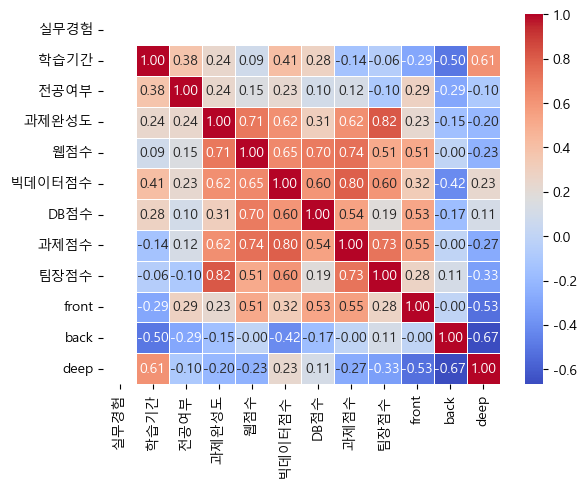

In [309]:
plant_numberic = data.select_dtypes('number')
correlation_matrix = plant_numberic.corr()

plt.Figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# 분석 알고리즘 및 모델

## A. 통계 기반 분석

In [310]:
data

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S104,0.0,1,0.0,2,3.0,1.0,3.0,0,1,0,0,0
1,S107,0.0,1,0.0,0,1.0,1.0,2.0,0,0,0,0,0
2,S103,0.0,1,0.0,3,4.0,4.0,3.0,4,4,0,0,0
3,S108,0.0,1,0.0,1,2.0,2.0,2.0,1,0,-1,-1,1
4,S109,0.0,1,1.0,1,4.0,3.0,4.0,3,0,1,0,0
5,S110,0.0,1,0.0,1,3.0,1.0,3.0,1,0,-1,1,0
6,S105,0.0,1,0.0,1,2.0,1.0,1.0,0,1,-1,1,0
7,S102,0.0,2,1.0,3,3.0,3.0,3.0,3,3,0,0,0
8,S111,0.0,1,1.0,1,1.0,1.0,1.0,0,0,-1,0,0
9,S101,0.0,1,1.0,1,2.0,1.0,2.0,0,0,0,0,0


In [311]:
dataCollect = pd.DataFrame()
dataCollect['ID'] = data['ID']
dataCollect['front'] = 0
dataCollect['back'] = 0
dataCollect['ai'] = 0
dataCollect['leader'] = 0

dataCollect['front'] += data['웹점수'] * 0.51 + data['front'] + data['실무경험'] * 0 + data['학습기간'] * 0.29 + data['전공여부'] *0.29 + data['과제완성도'] * 0.23 + data['과제점수'] * 0.55
dataCollect['back'] += data['DB점수'] * 0.17 + data['back'] + data['실무경험'] * 0 + data['학습기간'] * 0.50 + data['전공여부'] * 0.29 + data['과제완성도'] * 0.15 + data['과제점수'] * 0.00
dataCollect['ai'] += data['빅데이터점수'] * 0.23 + data['deep'] + data['실무경험'] * 0+ data['학습기간'] * 0.61 + data['전공여부'] * 0.10 + data['과제완성도'] * 0.20 + data['과제점수'] * 0.27
dataCollect['leader'] += data['팀장점수']



In [312]:
dataCollect

,ID,front,back,ai,leader
0,S104,2.28,1.31,1.24,1
1,S107,0.80,0.84,0.84,0
2,S103,5.22,1.46,3.21,4
3,S108,1.09,-0.01,2.54,0
4,S109,5.50,1.62,2.41,0
5,S110,1.60,2.16,1.31,0
6,S105,0.54,1.82,1.04,1
7,S102,4.74,2.25,3.42,3
8,S111,0.32,1.11,1.14,0
9,S101,1.83,1.28,1.14,0


<Axes: >

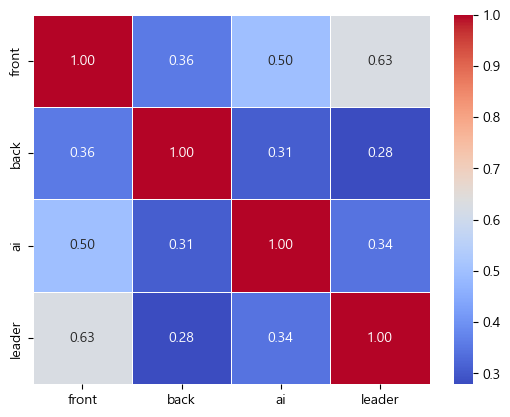

In [313]:
plant_numberic = dataCollect.select_dtypes('number')
correlation_matrix = plant_numberic.corr()

plt.Figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [320]:
data

In [321]:
testdata = pd.DataFrame()
testdata = pd.concat([data, dataCollect], axis=1)
testdata

,ID,front,back,ai,leader
0,S104,2.28,1.31,1.24,1
1,S107,0.80,0.84,0.84,0
2,S103,5.22,1.46,3.21,4
3,S108,1.09,-0.01,2.54,0
4,S109,5.50,1.62,2.41,0
5,S110,1.60,2.16,1.31,0
6,S105,0.54,1.82,1.04,1
7,S102,4.74,2.25,3.42,3
8,S111,0.32,1.11,1.14,0
9,S101,1.83,1.28,1.14,0


<Axes: >

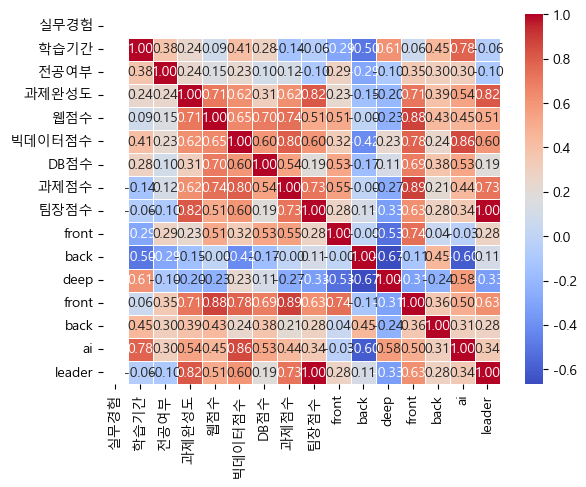

In [315]:
plant_numberic = testdata.select_dtypes('number')
correlation_matrix = plant_numberic.corr()

plt.Figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [ ]:
# 각 조의 능력의 편차가 가장 작게 되도록
value = []
for val in range(10000):
    user = []
    for i in range(len(dataCollect)):
        user.append([dataCollect.loc[i, 'ID'], dataCollect.loc[i, 'front'] + dataCollect.loc[i, 'back'] + dataCollect.loc[i, 'ai'], dataCollect.loc[i, 'leader']])

    user.sort(key=lambda x : x[1])
    # print(user)

    avg = sum(x[1] for x in user)/len(user)
    # print(avg)

    count = math.floor(len(dataCollect) / 3)
    left = len(dataCollect) % 3
    
    teamcount = [3 for i in range(count)]
    teamscore = []
    team = []

    for i in range(left):
        teamcount[i] += 1
        
    for i in range(count):
        temp = user.pop()
        team.append([temp])
        teamscore.append([temp[1]])
        teamcount[i] -= 1
        
    # print(len(team))
    # print(len(teamcount))
    shuffle(user)

    for u in user:
        score = u[1]
        temp_arr = []
        for i in range(count):
            if teamcount[i]:
                # temp_arr.append([i, (sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1)])
                temp_arr.append([i, ((sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1) - avg) ** 2])
        
        temp_arr.sort(key=lambda x : x[1])
        # print(temp_arr)
        team[int(temp_arr[0][0])].append(u)
        teamcount[int(temp_arr[0][0])] -= 1
    
    sumdata = 0
    for i in range(count):
        sumdata += ((sum(x[1] for x in team[i])) / (len(team[i])) - avg) ** 2
    
    value.append([i, sumdata ** 0.5, team])
    print(f"{val} is finished")

value.sort(key=lambda x : x[1])
team = (value[0][2])

# print(team)
print([x[0] for x in team[0]], (sum(x[1] for x in team[0])) / (len(team[0])))
print([x[0] for x in team[1]], (sum(x[1] for x in team[1])) / (len(team[1])))
print([x[0] for x in team[2]], (sum(x[1] for x in team[2])) / (len(team[2])))
print([x[0] for x in team[3]], (sum(x[1] for x in team[3])) / (len(team[3])))
print([x[0] for x in team[4]], (sum(x[1] for x in team[4])) / (len(team[4])))

0 is finished
1 is finished
2 is finished
3 is finished
4 is finished
5 is finished
6 is finished
7 is finished
8 is finished
9 is finished
10 is finished
11 is finished
12 is finished
13 is finished
14 is finished
15 is finished
16 is finished
17 is finished
18 is finished
19 is finished
20 is finished
21 is finished
22 is finished
23 is finished
24 is finished
25 is finished
26 is finished
27 is finished
28 is finished
29 is finished
30 is finished
31 is finished
32 is finished
33 is finished
34 is finished
35 is finished
36 is finished
37 is finished
38 is finished
39 is finished
40 is finished
41 is finished
42 is finished
43 is finished
44 is finished
45 is finished
46 is finished
47 is finished
48 is finished
49 is finished
50 is finished
51 is finished
52 is finished
53 is finished
54 is finished
55 is finished
56 is finished
57 is finished
58 is finished
59 is finished
60 is finished
61 is finished
62 is finished
63 is finished
64 is finished
65 is finished
66 is finished
67 is

IndexError: list index out of range

In [318]:
# 각 조의 능력의 편차가 가장 작게 되도록
value = []
for val in range(10000):
    user = []
    for i in range(len(dataCollect)):
        user.append([dataCollect.loc[i, 'ID'], dataCollect.loc[i, 'front'] + dataCollect.loc[i, 'back'] + dataCollect.loc[i, 'ai'], dataCollect.loc[i, 'leader']])

    user.sort(key=lambda x : x[1])
    # print(user)

    avg = sum(x[1] for x in user)/len(user)
    # print(avg)

    count = math.floor(len(dataCollect) / 4)
    left = len(dataCollect) % 4
    
    teamcount = [4 for i in range(count)]
    teamscore = []
    team = []

    for i in range(left):
        teamcount[i] += 1
        
    for i in range(count):
        temp = user.pop()
        team.append([temp])
        teamscore.append([temp[1]])
        teamcount[i] -= 1
        
    # print(len(team))
    # print(len(teamcount))
    shuffle(user)

    for u in user:
        score = u[1]
        temp_arr = []
        for i in range(count):
            if teamcount[i]:
                # temp_arr.append([i, (sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1)])
                temp_arr.append([i, ((sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1) - avg) ** 2])
        
        temp_arr.sort(key=lambda x : x[1])
        # print(temp_arr)
        team[int(temp_arr[0][0])].append(u)
        teamcount[int(temp_arr[0][0])] -= 1
    
    sumdata = 0
    for i in range(count):
        sumdata += ((sum(x[1] for x in team[i])) / (len(team[i])) - avg) ** 2
    
    value.append([i, sumdata ** 0.5, team])
    print(f"{val} is finished")

value.sort(key=lambda x : x[1])
team = (value[0][2])

# print(team)
print('-------------------------------')
data = team[0].sort(key=lambda x : (-x[2], -x[1]))
print('팀0 || 팀장: ', team[0][0][0])
print([x[0] for x in team[0]], (sum(x[1] for x in team[0])) / (len(team[0])))
print('-------------------------------')
data = team[1].sort(key=lambda x : (-x[2], -x[1]))
print('팀1 || 팀장: ', team[1][0][0])
print([x[0] for x in team[1]], (sum(x[1] for x in team[1])) / (len(team[1])))
print('-------------------------------')
data = team[2].sort(key=lambda x : (-x[2], -x[1]))
print('팀2 || 팀장: ', team[2][0][0])
print([x[0] for x in team[2]], (sum(x[1] for x in team[2])) / (len(team[2])))
print('-------------------------------')

# print([x[0] for x in team[3]], (sum(x[1] for x in team[3])) / (len(team[3])))
# print([x[0] for x in team[4]], (sum(x[1] for x in team[4])) / (len(team[4])))

0 is finished
1 is finished
2 is finished
3 is finished
4 is finished
5 is finished
6 is finished
7 is finished
8 is finished
9 is finished
10 is finished
11 is finished
12 is finished
13 is finished
14 is finished
15 is finished
16 is finished
17 is finished
18 is finished
19 is finished
20 is finished
21 is finished
22 is finished
23 is finished
24 is finished
25 is finished
26 is finished
27 is finished
28 is finished
29 is finished
30 is finished
31 is finished
32 is finished
33 is finished
34 is finished
35 is finished
36 is finished
37 is finished
38 is finished
39 is finished
40 is finished
41 is finished
42 is finished
43 is finished
44 is finished
45 is finished
46 is finished
47 is finished
48 is finished
49 is finished
50 is finished
51 is finished
52 is finished
53 is finished
54 is finished
55 is finished
56 is finished
57 is finished
58 is finished
59 is finished
60 is finished
61 is finished
62 is finished
63 is finished
64 is finished
65 is finished
66 is finished
67 is

In [181]:
# 각 조의 능력의 편차가 가장 작게 되도록
value = []
for val in range(10000):
    user = []
    for i in range(len(dataCollect)):
        user.append([dataCollect.loc[i, 'ID'], dataCollect.loc[i, 'front'] + dataCollect.loc[i, 'back'] + dataCollect.loc[i, 'ai'], dataCollect.loc[i, 'leader']])

    user.sort(key=lambda x : x[1])
    # print(user)

    avg = sum(x[1] for x in user)/len(user)
    # print(avg)

    count = math.floor(len(dataCollect) / 5)
    left = len(dataCollect) % 5
    
    teamcount = [5 for i in range(count)]
    teamscore = []
    team = []

    for i in range(left):
        teamcount[i] += 1
        
    for i in range(count):
        temp = user.pop()
        team.append([temp])
        teamscore.append([temp[1]])
        teamcount[i] -= 1
        
    # print(len(team))
    # print(len(teamcount))
    shuffle(user)

    for u in user:
        score = u[1]
        temp_arr = []
        for i in range(count):
            if teamcount[i]:
                # temp_arr.append([i, (sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1)])
                temp_arr.append([i, ((sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1) - avg) ** 2])
        
        temp_arr.sort(key=lambda x : x[1])
        # print(temp_arr)
        team[int(temp_arr[0][0])].append(u)
        teamcount[int(temp_arr[0][0])] -= 1
    
    sumdata = 0
    for i in range(count):
        sumdata += ((sum(x[1] for x in team[i])) / (len(team[i])) - avg) ** 2
    
    value.append([i, sumdata ** 0.5, team])
    print(f"{val} is finished")

value.sort(key=lambda x : x[1])
team = (value[0][2])

# print(team)
print('-------------------------------')
data = team[0].sort(key=lambda x : (-x[2], -x[1]))
print('팀0 || 팀장: ', team[0][0][0])
print([x[0] for x in team[0]], (sum(x[1] for x in team[0])) / (len(team[0])))
print('-------------------------------')
data = team[1].sort(key=lambda x : (-x[2], -x[1]))
print('팀1 || 팀장: ', team[1][0][0])
print([x[0] for x in team[1]], (sum(x[1] for x in team[1])) / (len(team[1])))
print('-------------------------------')
data = team[2].sort(key=lambda x : (-x[2], -x[1]))
print('팀2 || 팀장: ', team[2][0][0])
print([x[0] for x in team[2]], (sum(x[1] for x in team[2])) / (len(team[2])))
print('-------------------------------')
# print([x[0] for x in team[3]], (sum(x[1] for x in team[3])) / (len(team[3])))
# print([x[0] for x in team[4]], (sum(x[1] for x in team[4])) / (len(team[4])))

0 is finished
1 is finished
2 is finished
3 is finished
4 is finished
5 is finished
6 is finished
7 is finished
8 is finished
9 is finished
10 is finished
11 is finished
12 is finished
13 is finished
14 is finished
15 is finished
16 is finished
17 is finished
18 is finished
19 is finished
20 is finished
21 is finished
22 is finished
23 is finished
24 is finished
25 is finished
26 is finished
27 is finished
28 is finished
29 is finished
30 is finished
31 is finished
32 is finished
33 is finished
34 is finished
35 is finished
36 is finished
37 is finished
38 is finished
39 is finished
40 is finished
41 is finished
42 is finished
43 is finished
44 is finished
45 is finished
46 is finished
47 is finished
48 is finished
49 is finished
50 is finished
51 is finished
52 is finished
53 is finished
54 is finished
55 is finished
56 is finished
57 is finished
58 is finished
59 is finished
60 is finished
61 is finished
62 is finished
63 is finished
64 is finished
65 is finished
66 is finished
67 is

[['S07', np.float64(9.42), np.int64(2)], ['S10', np.float64(13.45), np.int64(0)], ['S06', np.float64(10.93), np.int64(0)], ['S13', np.float64(8.950000000000001), np.int64(0)], ['S01', np.float64(6.01), np.int64(0)]]
팀0 || 팀장:  S07


## B. 머신러닝/군집화 기반 

## C. 최적화 기반 팀 편성 알고리즘